In [10]:
%matplotlib inline

import os, random, time, sys, warnings

import numpy as np
import scipy as sp
import pandas as pd
import torch
import src.utils as utils

# import plotting libraries
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
import seaborn as sns
sns.set_style("white")
from src.plotting import my_reg_plot

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [11]:
save_figs = True

In [12]:
# directories
# datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
# modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/pytorch/model'
# # modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/pytorch/archive/model'
# outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

datadir = '/Users/ahmad/software/snaplab_github/neuro_rnn/data'
modeldir = '/Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model/5_models_100_runs'
outdir = modeldir
model_params_file = os.path.join(datadir, 'model_params.csv')
# outdir = '/Users/ahmad/data/rutgers/neuro_rnn/results/figs'

model_params = utils.load_params_csv(model_params_file)

# data parameters
dt = 100


# Model performance


Tasks:
['PerceptualDecisionMaking-v0', 'MultiSensoryIntegration-v0', 'ContextDecisionMaking-v0']

Kernel types:
['S-A RNN', 'Eucl. RNN', 'mRNNr', 'mRNNn', 'RNNn']

Curve index: 0
PerceptualDecisionMaking-v0    0
sa_axis    S-A RNN    0
task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-100-25000_wmask-True-14-27_reg-l2-0.002-sa_axis

Curve index: 1
MultiSensoryIntegration-v0    1
sa_axis    S-A RNN    0
task-MultiSensoryIntegration-v0-70-400_model-rnn-tanh-100-32-0.001-100-25000_wmask-True-14-27_reg-l2-0.002-sa_axis

Curve index: 2
ContextDecisionMaking-v0    2
sa_axis    S-A RNN    0
task-ContextDecisionMaking-v0-80-400_model-rnn-tanh-100-32-0.001-100-25000_wmask-True-14-27_reg-l2-0.002-sa_axis

Curve index: 3
PerceptualDecisionMaking-v0    0
euclidean    Eucl. RNN    1
task-PerceptualDecisionMaking-v0-125-400_model-rnn-tanh-100-32-0.001-100-25000_wmask-True-14-27_reg-l2-0.002-euclidean

Curve index: 4
MultiSensoryIntegration-v0    1
euclidean    Eucl. RNN    1
task

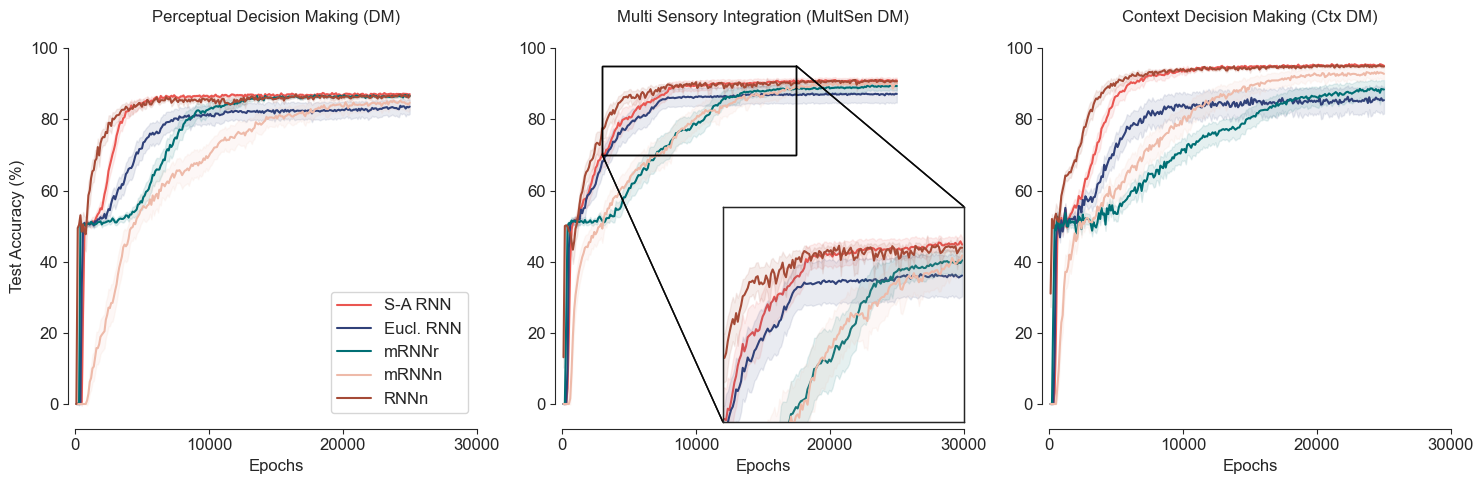

In [13]:
# import colors
color_palette = utils.get_my_colors(cat_trio=False, as_list=True)

# how many tasks?
task_names_all = model_params.loc[:, 'task']
task_names = []
[task_names.append(item) for item in task_names_all if item not in task_names]
n_tasks = len(task_names)
print('\nTasks:')
print(task_names)

# how many kernels?
kernel_labels_all = model_params.loc[:, 'kernel_label']
kernel_labels = []
[kernel_labels.append(item) for item in kernel_labels_all if item not in kernel_labels]
n_kernels = len(kernel_labels)
print('\nKernel types:')
print(kernel_labels)

# initialise figure
size_scale = 2
font_size = 6 * size_scale
f, ax = plt.subplots(1, n_tasks, figsize=(7.5*size_scale, 2.5*size_scale))
# f, ax = plt.subplots(1, n_tasks, figsize=(2.5*size_scale, 2.5*size_scale))
if n_tasks == 1:
    ax = np.array(ax)
    ax = np.reshape(ax, n_tasks)
plt.rcParams['font.size'] = font_size

for model_idx in np.arange(len(model_params)):
    
    print('\nCurve index: ' + str(model_idx))
    
    # get model details
    task = model_params.task.iloc[model_idx] 
    kernel_type = model_params.kernel_type.iloc[model_idx] 
    mask_weights = model_params.mask_weights.iloc[model_idx] 
    decision = model_params.decision.iloc[model_idx] 
    reg_weight = model_params.reg_weight.iloc[model_idx] 
    n_epochs = model_params.n_epochs.iloc[model_idx] 
    n_runs = model_params.n_runs.iloc[model_idx] 
    hidden_size = model_params.hidden_size.iloc[model_idx]
    batch_size = model_params.batch_size.iloc[model_idx]
    seq_len_multi = model_params.seq_len_multi.iloc[model_idx]
    seq_len = utils.get_seq_len(task, decision, seq_len_multi)
    rnn_model = model_params.rnn_model.iloc[model_idx]
    learning_rate = model_params.learning_rate.iloc[model_idx]
    reg_type = model_params.reg_type.iloc[model_idx]
    n_io = utils.get_n_io(mask_weights=mask_weights, hidden_size=hidden_size)
    kernel_label = model_params.kernel_label.iloc[model_idx]
    
    # prepare config
    timing = {'decision': decision}
    env_kwargs = {'dt': dt, 'timing': timing}
    config = {
        'dt': dt, 
        'batch_size': batch_size, 
        'rnn_model': rnn_model, 
        'n_runs': n_runs, 
        'n_epochs': n_epochs, 
        'learning_rate': learning_rate, 
        'mask_weights': mask_weights, 
        'hidden_size': hidden_size, 
        'reg_type': reg_type,
        'reg_weight': reg_weight,
        'n_io': n_io,
        'env_kwargs': env_kwargs,
        'n_runs': n_runs,
        'n_epochs': n_epochs,
        'task': task,
        'seq_len': seq_len,
        'kernel_type': kernel_type
    }
    
    # determine task index
    task_index = task_names.index(task)
    print(task + '    ' + str(task_index))
    
    # determine kernel index
    kernel_index = kernel_labels.index(kernel_label)
    print(kernel_type + '    ' + kernel_label + '    ' + str(kernel_index))

    # get data file name
    file_str = utils.get_file_str(config)
    print(file_str)
    
    try:
        
        # load data
        log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True)
        
        # extract accuracy from each run
        test_accuracy = np.zeros((n_runs,log_args[0]['test_accuracy'].shape[0]-1))
        for run in np.arange(n_runs):
            test_accuracy[run,:] = log_args[run]['test_accuracy'][1:] * 100

        n_epochs_actual = test_accuracy.shape[1] * 100
        n_logged_epochs = int(n_epochs_actual / 100)
        x_step = int(n_epochs_actual / (n_logged_epochs))
        x = np.arange(x_step, n_epochs_actual + x_step, x_step)

        # compute mean and ci
        accuracy_mean = test_accuracy.mean(axis=0)
        accuracy_std = test_accuracy.std(axis=0)
        ci = 1.96 * (accuracy_std / np.sqrt(test_accuracy.shape[0]))
        ci_lower = accuracy_mean - ci
        ci_upper = accuracy_mean + ci

        # plot
        ax[task_index].plot(x, accuracy_mean, color=color_palette[kernel_index], label=str(kernel_label))
        ax[task_index].fill_between(x, ci_lower, ci_upper, color=color_palette[kernel_index], alpha=0.1)

        # inset axis
        if task_index == 1:
            x1, x2, y1, y2 = 3000, 17500, 70, 95
            axins = ax[task_index].inset_axes([0.4, 0, 0.6, 0.55], xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
            axins.plot(x[int(x1/100)-1:int(x2/100)-1], accuracy_mean[int(x1/100)-1:int(x2/100)-1], color=color_palette[kernel_index])
            axins.fill_between(x[int(x1/100)-1:int(x2/100)-1], ci_lower[int(x1/100)-1:int(x2/100)-1], ci_upper[int(x1/100)-1:int(x2/100)-1], color=color_palette[kernel_index], alpha=0.1)
            axins.patch.set_alpha(0)
            ax[task_index].indicate_inset_zoom(axins, edgecolor="black")
        
    except:
        
        print("An error occurred:", sys.exc_info()[0])
        print("Exception message:", sys.exc_info()[1])

# set title and labels
for task_index in np.arange(n_tasks):
    ax[task_index].set_xlabel('Epochs', fontsize=font_size)
    if task_index == 0: ax[task_index].set_ylabel('Test Accuracy (%)', fontsize=font_size)
    ax[task_index].set_xlim([0, 30000])
    ax[task_index].set_ylim([-5, 105])
    ax[task_index].set_xticks(np.arange(0,30000+1,10000))
    ax[task_index].set_yticks(np.arange(0,100+1,20))
    ax[task_index].tick_params(bottom=True,left=True)
    if task_index == 0:
        ax[task_index].legend(loc='lower right')
    ax[task_index].set_title(utils.get_task_label(task_names[task_index]), fontsize=font_size)

sns.despine(offset=5, trim=True, left=False, right=True, top=True, bottom=False)

# file_str = '-'.join(file_str.split('-')[:-1])
# f.suptitle(file_str)
f.tight_layout()
plt.show()

# save svg
if save_figs:
    try:
        file_str = 'accuracy_r{:}_d{:}.svg'.format(str(reg_weight).split('.')[1], decision)
    except:
        file_str = 'accuracy_r{:}_d{:}.svg'.format(reg_weight, decision)
    f.savefig(os.path.join(outdir, file_str), dpi=300, bbox_inches='tight', pad_inches=0.01)